In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df_exp  = pd.read_csv('raw/df_final_experiment_clients.csv')
df_demo = pd.read_csv('raw/df_final_demo.csv')
df_wd1  = pd.read_csv('raw/df_final_web_data_pt_1.csv', parse_dates=['date_time'])
df_wd2  = pd.read_csv('raw/df_final_web_data_pt_2.csv', parse_dates=['date_time'])



In [2]:
web = pd.concat([df_wd1, df_wd2], ignore_index=True) # Combine the two web data files into one dataframe.

In [3]:
# After your concat
web = pd.concat([df_wd1, df_wd2], ignore_index=True)

# Save it
web.to_csv('raw/df_final_web_data.csv', index=False)

In [4]:
df_exp.head()

,client_id,Variation
0,9988021,Test
1,8320017,Test
2,4033851,Control
3,1982004,Test
4,9294070,Control


In [5]:
web = web.merge(df_exp[['client_id', 'Variation']], on='client_id', how='left') # Merge the web data with the experiment data to get the variation for each client.

In [6]:
web.head()

,client_id,visitor_id,visit_id,process_step,date_time,Variation
0,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:27:07,Test
1,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:26:51,Test
2,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:19:22,Test
3,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:19:13,Test
4,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:18:04,Test


In [7]:
step_order = ['start', 'step_1', 'step_2', 'step_3', 'confirm']
step_rank = {step: i for i, step in enumerate(step_order)}

In [8]:
web['step_rank'] = web['process_step'].map(step_rank)

Clients who have competed the last step till confirmation   

In [9]:
complete_step = web[web['process_step']=='confirm']['client_id'].unique()
complete_step

array([8320017, 4033851, 1982004, ..., 9563467, 9895983, 9668240],
      shape=(81145,))

In [10]:
all_clients = web[['client_id', 'Variation']].drop_duplicates()

In [11]:
all_clients['completed'] = all_clients['client_id'].isin(complete_step).astype(int)

In [12]:
completion = all_clients.groupby('Variation')['completed'].agg(['sum', 'count']).reset_index()
completion.columns = ['variation','completed', 'total']
completion['completion_rate'] = completion['completed'] / completion['total']
print(completion)

  variation  completed  total  completion_rate
0   Control      15434  23532         0.655873
1      Test      18687  26968         0.692932


**There is a 0.04 difference in completion in the old design and new design** 

Funnel analysis

In [13]:
visit_max = (
    web.groupby(['visit_id', 'Variation'])['step_rank'].max().reset_index().rename(columns={'step_rank': 'max_step_rank'})
)
visit_max

,visit_id,Variation,max_step_rank
0,100012776_37918976071_457913,Test,4
1,100019538_17884295066_43909,Test,4
2,100022086_87870757897_149620,Test,4
3,100030127_47967100085_936361,Control,0
4,100037962_47432393712_705583,Control,1
...,...,...,...
69320,999971096_28827267783_236076,Test,4
69321,999976049_95772503197_182554,Test,4
69322,999984454_18731538378_781808,Test,4
69323,999985675_64610694964_443659,Control,4


Control - start:  100.0%
Control - step_1:  76.5%
Control - step_2:  65.6%
Control - step_3:  59.3%
Control - confirm:  49.8%
Test - start:  100.0%
Test - step_1:  86.3%
Test - step_2:  75.8%
Test - step_3:  68.9%
Test - confirm:  58.5%


([<matplotlib.axis.XTick at 0x1169dd940>,
 [Text(0, 0, 'start'),
  Text(1, 0, 'step_1'),
  Text(2, 0, 'step_2'),
  Text(3, 0, 'step_3'),
  Text(4, 0, 'confirm')])

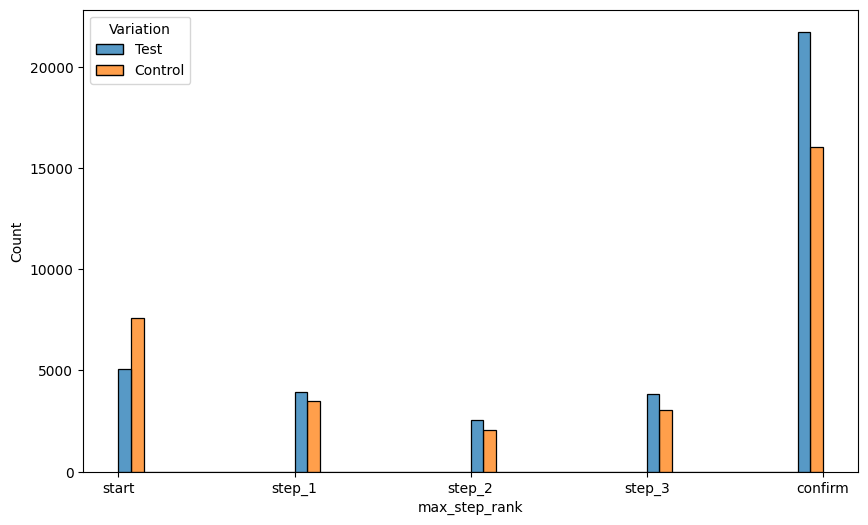

In [14]:
for variation in ['Control', 'Test']:
    subset = visit_max[visit_max['Variation'] == variation]
    total = len(subset)
    for step in step_order:
        rank = step_rank[step]
        reached = (subset['max_step_rank'] >= rank).sum()
        print(f"{variation} - {step}: {reached/total*100: .1f}%")

plt.figure(figsize=(10, 6))
sns.histplot(visit_max, x='max_step_rank', hue='Variation', multiple='dodge', shrink=1)
plt.xticks(range(len(step_order)), step_order)

Key takeaway

- The Test version improves retention across the entire funnel, reducing drop-off by roughly 8–10 percentage points at each stage.
- This suggests the Test changes are likely having a meaningful positive impact on user progression and completion.

**Time Spent per step**

In [15]:
web_sorted = web.sort_values(['visit_id', 'date_time'])
web_sorted

,client_id,visitor_id,visit_id,process_step,date_time,Variation,step_rank
108614,3561384,451664975_1722933822,100012776_37918976071_457913,confirm,2017-04-26 13:22:17,Test,4
108613,3561384,451664975_1722933822,100012776_37918976071_457913,confirm,2017-04-26 13:23:09,Test,4
447951,9056452,306992881_89423906595,1000165_4190026492_760066,start,2017-06-04 01:07:29,NaN,0
447950,9056452,306992881_89423906595,1000165_4190026492_760066,step_1,2017-06-04 01:07:32,NaN,1
447949,9056452,306992881_89423906595,1000165_4190026492_760066,step_2,2017-06-04 01:07:56,NaN,2
...,...,...,...,...,...,...,...
539055,7149380,483112224_46340533900,999992932_41666455053_671149,step_1,2017-06-06 15:46:24,NaN,1
539054,7149380,483112224_46340533900,999992932_41666455053_671149,step_2,2017-06-06 15:47:32,NaN,2
539072,7149380,483112224_46340533900,999992932_41666455053_671149,step_3,2017-06-06 16:01:46,NaN,3
539071,7149380,483112224_46340533900,999992932_41666455053_671149,confirm,2017-06-06 16:04:08,NaN,4


In [16]:
web_sorted['next_time'] = web_sorted.groupby('visit_id')['date_time'].shift(-1)
web_sorted['time_diff'] = (web_sorted['next_time'] - web_sorted['date_time']).dt.total_seconds()


In [17]:
time_data= web_sorted[
            (web_sorted['time_diff'] >= 0) &
            (web_sorted['time_diff'] <= 1800)] # 30 mins = 1800 seconds

In [18]:
time_summary = (time_data.groupby(['Variation', 'process_step'])['time_diff']).median().reset_index()

print(time_summary)

  Variation process_step  time_diff
0   Control      confirm       42.0
1   Control        start       18.0
2   Control       step_1       20.0
3   Control       step_2       64.0
4   Control       step_3       71.0
5      Test      confirm       91.0
6      Test        start       14.0
7      Test       step_1       27.0
8      Test       step_2       61.0
9      Test       step_3       57.0


**Error Rate**

A error rate would be when a user is going backwards to complete the infos e.g., going backward from step 3 to step 2

In [19]:
web_sorted['next_step'] = web_sorted.groupby('visit_id')['process_step'].shift(-1)
web_sorted['next_step_rank'] = web_sorted['next_step'].map(step_rank)

backward_data = web_sorted[
    (web_sorted['next_step_rank'] < web_sorted['step_rank']) ]

In [20]:
total_errors = (
    web_sorted[web_sorted['next_step'].notna()].groupby(['Variation', 'process_step']).size().reset_index(name='total_errors')  
)
total_errors

,Variation,process_step,total_errors
0,Control,confirm,2270
1,Control,start,37976
2,Control,step_1,26180
3,Control,step_2,24429
4,Control,step_3,20549
5,Test,confirm,4411
6,Test,start,47031
7,Test,step_1,35634
8,Test,step_2,29665
9,Test,step_3,24114


In [21]:
backward = backward_data.groupby(['Variation', 'process_step']).size().reset_index(name='backward_count')
backward

,Variation,process_step,backward_count
0,Control,confirm,859
1,Control,step_1,2503
2,Control,step_2,2167
3,Control,step_3,4253
4,Test,confirm,498
5,Test,step_1,6408
6,Test,step_2,4785
7,Test,step_3,4754


In [22]:
error_df = total_errors.merge(backward, on=['Variation', 'process_step'], how='left')


In [23]:
error_df['backward_count'] = error_df['backward_count'].fillna(0)
error_df['error_rate'] = error_df['backward_count'] / error_df['total_errors']
print(error_df)

  Variation process_step  total_errors  backward_count  error_rate
0   Control      confirm          2270           859.0    0.378414
1   Control        start         37976             0.0    0.000000
2   Control       step_1         26180          2503.0    0.095607
3   Control       step_2         24429          2167.0    0.088706
4   Control       step_3         20549          4253.0    0.206969
5      Test      confirm          4411           498.0    0.112900
6      Test        start         47031             0.0    0.000000
7      Test       step_1         35634          6408.0    0.179828
8      Test       step_2         29665          4785.0    0.161301
9      Test       step_3         24114          4754.0    0.197147


**Exporting Cleaned CSVs for Tableau**

In [25]:
# 1. Completion rate by group
completion.to_csv('tableau/completion_rate.csv', index=False)

# 2. Error rate by step and group
error_df.to_csv('tableau/error_rate.csv', index=False)

# 3. Demographics merged with experiment group
demographics = pd.merge(df_exp, df_demo, on='client_id', how='inner')
demographics.to_csv('tableau/demographics.csv', index=False)

# 4. Full web data with Variation (already merged in KPI notebook)
web.to_csv('tableau/web_with_variation.csv', index=False)